In [1]:
import pandas as pd

In [2]:
# Load Medicaid enrollment CSV
df = pd.read_csv('/content/Medicaid_enrollment.csv')
df.head()

,State,Total Medicaid Enrollees,Total VIII Group Enrollees,Total VIII Group Newly Eligible Enrollees,Total VIII Group Not Newly Eligible Enrollees,Updated Year,Updated Month,Enrollment Year,Enrollment Month,Notes
0,Alabama,1086326,NaN,NaN,NaN,2026,2,2025,4,NaN
1,Alaska,226450,71043.0,71042.0,1.0,2026,2,2025,4,Alaska expanded its Medicaid program by adopti...
2,Amer. Samoa,31150,NaN,NaN,NaN,2026,2,2025,4,NaN
3,Arizona,2169318,638010.0,125956.0,512054.0,2026,2,2025,4,NaN
4,Arkansas,805793,236894.0,229563.0,7331.0,2026,2,2025,4,NaN


In [4]:
# Remove any duplicate rows
df = df.drop_duplicates()

# Convert numeric columns to proper dtype
numeric_cols = ['Total Medicaid Enrollees', 'Total VIII Group Enrollees',
                'Total VIII Group Newly Eligible Enrollees',
                'Total VIII Group Not Newly Eligible Enrollees']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert Enrollment Month/Year to datetime for trend analysis
df['Enrollment_Date'] = pd.to_datetime(df['Enrollment Year'].astype(str) + '-' + df['Enrollment Month'].astype(str) + '-01')

In [5]:
# Total Medicaid Enrollees across all states
total_enrollees = df['Total Medicaid Enrollees'].sum()
print(f"Total Medicaid Enrollees (all states): {total_enrollees}")

# Total VIII Group Enrollees
total_viii_enrollees = df['Total VIII Group Enrollees'].sum()
print(f"Total VIII Group Enrollees (all states): {total_viii_enrollees}")

# State with highest VIII Group enrollment
top_state = df.loc[df['Total VIII Group Enrollees'].idxmax(), 'State']
print(f"State with highest VIII Group enrollment: {top_state}")

Total Medicaid Enrollees (all states): 500757880
Total VIII Group Enrollees (all states): 123727424.0
State with highest VIII Group enrollment: Totals


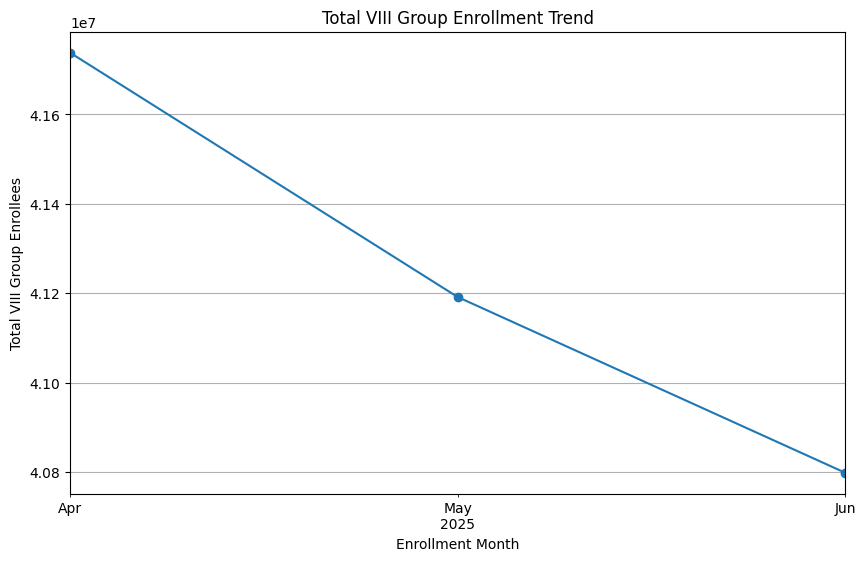

In [6]:
import matplotlib.pyplot as plt

# Aggregate total enrollment per month
monthly_trend = df.groupby('Enrollment_Date')['Total VIII Group Enrollees'].sum()

# Plot trend
plt.figure(figsize=(10,6))
monthly_trend.plot(kind='line', marker='o', title='Total VIII Group Enrollment Trend')
plt.ylabel('Total VIII Group Enrollees')
plt.xlabel('Enrollment Month')
plt.grid(True)
plt.show()

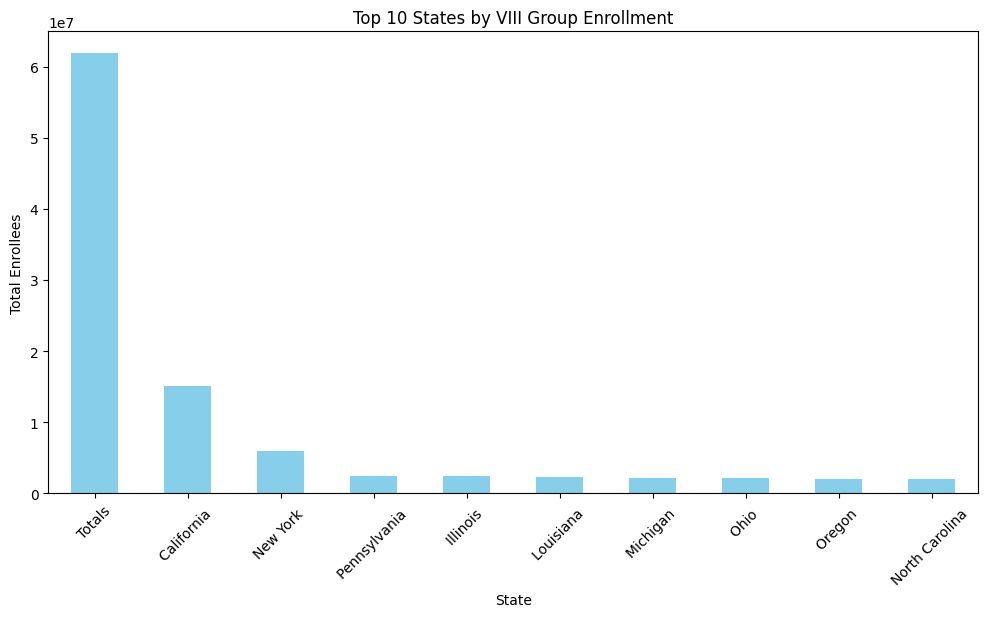

In [7]:
# Top 10 states by VIII Group enrollment
top_states = df.groupby('State')['Total VIII Group Enrollees'].sum().sort_values(ascending=False).head(10)

# Bar plot
plt.figure(figsize=(12,6))
top_states.plot(kind='bar', color='skyblue')
plt.title('Top 10 States by VIII Group Enrollment')
plt.ylabel('Total Enrollees')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.show()

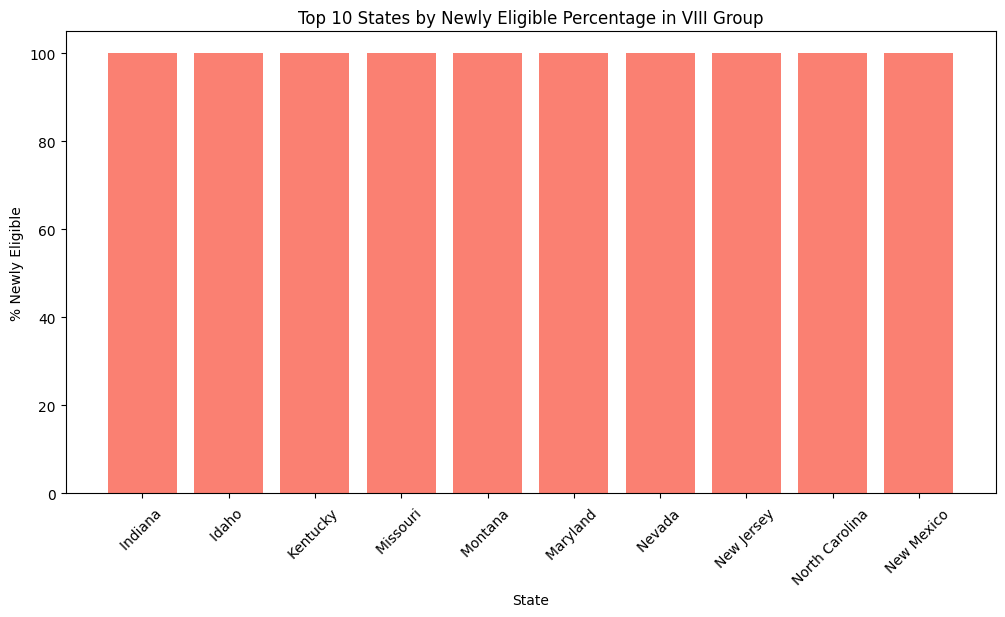

In [8]:
# Compare newly eligible vs not newly eligible across states
df['Newly_Eligible_Percentage'] = (df['Total VIII Group Newly Eligible Enrollees'] / df['Total VIII Group Enrollees']) * 100

# Top 10 states with highest percentage of newly eligible
top_newly_eligible = df[['State','Newly_Eligible_Percentage']].sort_values(by='Newly_Eligible_Percentage', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_newly_eligible['State'], top_newly_eligible['Newly_Eligible_Percentage'], color='salmon')
plt.title('Top 10 States by Newly Eligible Percentage in VIII Group')
plt.ylabel('% Newly Eligible')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.show()

In [9]:
df.to_csv('medicaid_cleaned.csv', index=False)